In [1]:
import torch
import os
from pathlib import Path
import logging
import numpy as np
# --- Add project root to sys.path ---
BASE_DIR = Path.cwd().parent.parent.parent
MODEL_PATH = BASE_DIR / "results" / "models"
DATA_DIR = BASE_DIR / "data" / "data_gnn"
ALL_DIR = DATA_DIR / "all"
RAW_DATA_DIR = BASE_DIR / "data" / "data_raw"
CACHE_DIR = BASE_DIR / "data" / "data_gnn"/ "cache"
# ------------------------------------

print(f"BASE_DIR: {BASE_DIR}")
print(f"MODEL_PATH: {MODEL_PATH}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"ALL_DIR: {ALL_DIR}")
print(f"RAW_DATA_DIR: {RAW_DATA_DIR}")

os.chdir(BASE_DIR)
from src.graph_modelling.models.astgcn import ASTGCN
from src.graph_modelling.datasets.no2_dataset import NO2DatasetLoader
import matplotlib.pyplot as plt

# A logger for this file
log = logging.getLogger(__name__)
log.setLevel(logging.INFO)

N_HOURS_IN = 72
N_HOURS_OUT = 24
N_HOURS_PRED = 24
OFFSET = 49

# === SETTINGS ===
target_time = -1         # Last forecasted timestep
target_feature = 0
node_names = {0: "Amsterdam", 1: "Utrecht", 2: "Rotterdam"}


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


BASE_DIR: /home/nick/bachelor-project/third-copy
MODEL_PATH: /home/nick/bachelor-project/third-copy/results/models
DATA_DIR: /home/nick/bachelor-project/third-copy/data/data_gnn
ALL_DIR: /home/nick/bachelor-project/third-copy/data/data_gnn/all
RAW_DATA_DIR: /home/nick/bachelor-project/third-copy/data/data_raw
Using device: cuda


In [2]:
import hydra
from omegaconf import DictConfig, OmegaConf
from hydra.utils import to_absolute_path
import os

# Path to your config directory relative to where you're running the notebook
config_path = "../scripts/conf"

# Optional: override config values (similar to command line arguments)
overrides = [
    "model=astgcn_like",
    "data=all_vars", 
    "training.batch_size=32"
]

# Initialize configuration
with hydra.initialize(version_base=None, config_path=config_path):
    # Compose the configuration
    cfg = hydra.compose(config_name="config", overrides=overrides)
    
# Now you can use cfg just like in your scripts
print(OmegaConf.to_yaml(cfg))

data:
  only_no2: false
  num_vars: 7
  cache_file: no2_dataset_cache.pkl
  force_reload: false
  sample_size: 1.0
  shuffle: true
  ratio:
  - 0.7
  - 0.15
  - 0.15
  use_time_split: true
  split_dates: null
  target_offset: 49
model:
  _target_: src.graph_modelling.models.astgcn_like.ASTGCN_Like
  block_channels: 32
  gru_channels: 32
  num_blocks: 2
seed: 34
base_dir: .
results_subdir: comparison_results
weights_file: null
training:
  n_lags: 72
  n_horizon: 24
  batch_size: 32
  n_step: 24
  n_epochs: 1000
  patience: 10
  skip_training: false
  load_model_path: null
  learning_rate: 0.0001
  weight_decay: 0.0001
track_energy: true
optuna:
  enabled: false
  study_name: no2_model_optimization
  storage: sqlite:///no2_models_optuna_4hrs.db
  n_trials: 100
  timeout: 21600
  direction: minimize
  n_eval_runs: 5
paths:
  model_save_name: final_model.pt
  history_save_name: training_history.json
  metrics_save_name: test_metrics.json
  tensorboard_subdir: tensorboard_logs
  plot_subdir

In [3]:
loader = NO2DatasetLoader(
    index=True,
    only_no2=False,
    force_reload=False,
    cache_file=str(CACHE_DIR),
    logger=log,
)

train_loader, val_loader, test_loader, edges, edge_weights, lambda_max = (
    loader.get_index_dataset(
        lags=cfg.training.n_lags,
        batch_size=cfg.training.batch_size,
        shuffle=cfg.data.shuffle,
        allGPU=device,
        ratio=list(cfg.data.ratio),
        only_no2=cfg.data.only_no2,
        sample_size=cfg.data.sample_size,
        horizon=cfg.training.n_horizon,
        cache=True,
        step_size=cfg.training.n_step,
        use_time_split=cfg.data.use_time_split,
        dask_batching=False,
        target_offset=cfg.data.target_offset,
    )
)

print(
    f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}"
)

Train batches: 21, Val batches: 3, Test batches: 3


In [4]:
model = ASTGCN(num_nodes=3, num_vars=7, timesteps=72, K=1, num_blocks=3, horizon=24, block_channels=48)
model.load_state_dict(torch.load("/home/nick/bachelor-project/third-copy/src/graph_modelling/models/final_model_weights/astgcn_tuned.pt"))
# check model weights
model.to(device)

ASTGCN(
  (model): ASTGCN(
    (_blocklist): ModuleList(
      (0): ASTGCNBlock(
        (_temporal_attention): TemporalAttention()
        (_spatial_attention): SpatialAttention()
        (_chebconv_attention): ChebConvAttention(7, 48, K=1, normalization=sym)
        (_time_convolution): Conv2d(48, 48, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
        (_residual_convolution): Conv2d(7, 48, kernel_size=(1, 1), stride=(1, 1))
        (_layer_norm): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
      )
      (1-2): 2 x ASTGCNBlock(
        (_temporal_attention): TemporalAttention()
        (_spatial_attention): SpatialAttention()
        (_chebconv_attention): ChebConvAttention(48, 48, K=1, normalization=sym)
        (_time_convolution): Conv2d(48, 48, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
        (_residual_convolution): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
        (_layer_norm): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
      )
    )

In [5]:
# Get a sample batch from test_loader to use for visualization
test_loader = test_loader
for batch in test_loader:
    test_batch = batch
    break

# Set model to evaluation mode
model.eval()

ASTGCN(
  (model): ASTGCN(
    (_blocklist): ModuleList(
      (0): ASTGCNBlock(
        (_temporal_attention): TemporalAttention()
        (_spatial_attention): SpatialAttention()
        (_chebconv_attention): ChebConvAttention(7, 48, K=1, normalization=sym)
        (_time_convolution): Conv2d(48, 48, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
        (_residual_convolution): Conv2d(7, 48, kernel_size=(1, 1), stride=(1, 1))
        (_layer_norm): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
      )
      (1-2): 2 x ASTGCNBlock(
        (_temporal_attention): TemporalAttention()
        (_spatial_attention): SpatialAttention()
        (_chebconv_attention): ChebConvAttention(48, 48, K=1, normalization=sym)
        (_time_convolution): Conv2d(48, 48, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
        (_residual_convolution): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
        (_layer_norm): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
      )
    )

In [6]:


def add_hooks_to_astgcn(model):
    """Add hooks to ASTGCN model to capture attention weights."""
    
    spatial_attention_weights = []
    temporal_attention_weights = []
    
    # Define hook functions for spatial and temporal attention
    def spatial_attention_hook(module, input, output):
        # Capture the spatial attention matrix
        if hasattr(module, '_S') and module._S is not None:
            spatial_attention_weights.append(module._S.detach().cpu())
    
    def temporal_attention_hook(module, input, output):
        # Capture the temporal attention matrix
        if hasattr(module, '_E') and module._E is not None:
            temporal_attention_weights.append(module._E.detach().cpu())
    
    # Loop through blocks and register hooks directly to attention modules
    for block in model.model._blocklist:
        # Hook into spatial attention
        block._spatial_attention.register_forward_hook(spatial_attention_hook)
        
        # Hook into temporal attention
        block._temporal_attention.register_forward_hook(temporal_attention_hook)
    
    model.spatial_attention_weights = spatial_attention_weights
    model.temporal_attention_weights = temporal_attention_weights
    
    return model


# Try the new hooks
model = add_hooks_to_astgcn(model)



# Explaining through Attention weights

In [7]:
def extract_feature_importance(model, batch, edges, edge_weights):
    """Extract feature importance from ASTGCN model by analyzing attention weights."""
    model.eval()
    
    with torch.no_grad():
        # Get data from batch
        x_batch, y_batch = batch
        
        # Get device and dtype from model
        device = next(model.parameters()).device
        dtype = next(model.parameters()).dtype
        
        # Move everything to the right device
        x_batch = x_batch.to(device=device, dtype=dtype)
        edges = edges.to(device)
        edge_weights = edge_weights.to(device=device, dtype=dtype)
        
        # Forward pass to calculate attention
        _ = model(x_batch, edges, edge_weights)
        
        # Create a list to store feature importance per block
        feature_importance = []
        
        # Analyze each block in the model
        for i, block in enumerate(model.model._blocklist):
            # Extract weights from the spatial attention module
            if hasattr(block._spatial_attention, '_W1'):
                # Get the tensor and check its dimensions
                w1_tensor = block._spatial_attention._W1.detach()
                
                # Print shape for debugging
                print(f"Block {i+1} _W1 shape: {w1_tensor.shape}")
                
                # Handle different tensor dimensions
                if len(w1_tensor.shape) == 1:
                    # For 1D tensor, just use abs values
                    feature_weights = w1_tensor.abs().cpu().numpy()
                elif len(w1_tensor.shape) == 2:
                    # For 2D tensor, mean over dimension 1
                    feature_weights = w1_tensor.abs().mean(dim=0).cpu().numpy()  # Changed from dim=1 to dim=0
                else:
                    # For higher dimensions, flatten to 2D first then mean over appropriate dim
                    flattened = w1_tensor.view(w1_tensor.shape[0], -1)
                    feature_weights = flattened.abs().mean(dim=1).cpu().numpy()
                
                feature_importance.append(feature_weights)
            # Try alternative parameter if _W1 doesn't exist
            elif hasattr(block._spatial_attention, 'lin'):
                # Some PyG implementations use linear layers instead of direct weight tensors
                lin_weight = block._spatial_attention.lin.weight.detach()
                print(f"Block {i+1} linear weight shape: {lin_weight.shape}")
                feature_weights = lin_weight.abs().mean(dim=0).cpu().numpy()
                feature_importance.append(feature_weights)
                
        return feature_importance
feature_importance = extract_feature_importance(model, test_batch, edges, edge_weights)


Block 1 _W1 shape: torch.Size([72])
Block 2 _W1 shape: torch.Size([72])
Block 3 _W1 shape: torch.Size([72])


Block 1 importance shape: (72,)
Truncated to 7 features
Normalized range: 0.0000 to 1.0000
Block 2 importance shape: (72,)
Truncated to 7 features
Normalized range: 0.0000 to 1.0000
Block 3 importance shape: (72,)
Truncated to 7 features
Normalized range: 0.0000 to 1.0000


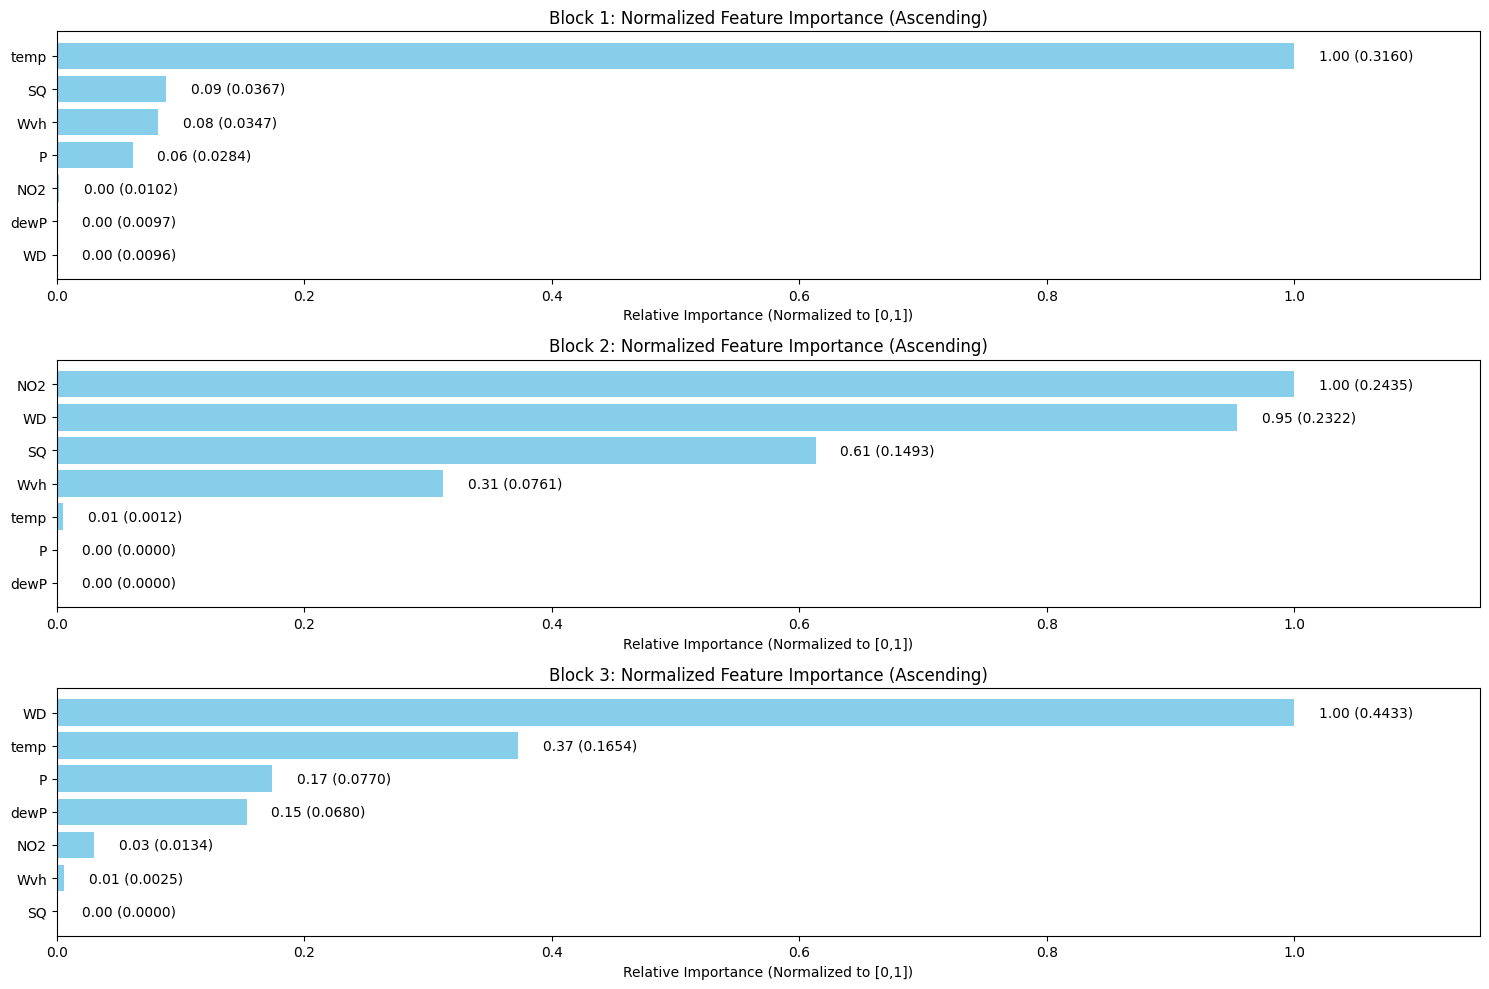

In [8]:
# Visualize feature importance with normalization and sorting by value (ascending order)
if feature_importance:
    plt.figure(figsize=(15, 10))
    
    # Feature names - update these to match your actual features
    feature_names = ["NO2", "P", "SQ", "WD", "Wvh", "dewP", "temp"]
    
    # For each block
    for i, importance in enumerate(feature_importance):
        plt.subplot(len(feature_importance), 1, i+1)
        
        # Print shape for debugging
        print(f"Block {i+1} importance shape: {importance.shape}")
        
        # Ensure length matches by truncating if necessary
        if len(importance) > len(feature_names):
            importance = importance[:len(feature_names)]
            print(f"Truncated to {len(importance)} features")
        
        # Normalize the importance values to [0,1] range
        if importance.max() > importance.min():
            normalized_importance = (importance - importance.min()) / (importance.max() - importance.min())
            print(f"Normalized range: {normalized_importance.min():.4f} to {normalized_importance.max():.4f}")
        else:
            normalized_importance = importance
            print(f"All importance values are equal: {importance[0]:.4f}")
        
        # Handle case with fewer importance values than feature names
        if len(normalized_importance) < len(feature_names):
            print(f"Warning: Only {len(normalized_importance)} importance values but {len(feature_names)} feature names")
            feature_names_subset = feature_names[:len(normalized_importance)]
            
            # Sort by importance values (ascending)
            sorted_indices = np.argsort(normalized_importance)  # Changed to ascending order
            sorted_importance = normalized_importance[sorted_indices]
            sorted_original = importance[sorted_indices]
            sorted_features = [feature_names_subset[idx] for idx in sorted_indices]
            
            # Create horizontal bar chart with normalized and sorted values
            y_pos = np.arange(len(sorted_importance))
            bars = plt.barh(y_pos, sorted_importance, align='center', color='skyblue')
            plt.yticks(y_pos, sorted_features)
            
            # Add value labels showing both normalized and original values
            for j, (v_norm, v_orig) in enumerate(zip(sorted_importance, sorted_original)):
                plt.text(v_norm + 0.02, j, f"{v_norm:.2f} ({v_orig:.4f})", va='center')
            
            plt.title(f'Block {i+1}: Normalized Feature Importance (Ascending)')
            plt.xlabel('Relative Importance (Normalized to [0,1])')
            continue
        
        # Sort by importance values (ascending)
        sorted_indices = np.argsort(normalized_importance)  # Changed to ascending order
        sorted_importance = normalized_importance[sorted_indices]
        sorted_original = importance[sorted_indices]
        sorted_features = [feature_names[idx] for idx in sorted_indices]
        
        # Create standard plot with sorted values
        y_pos = np.arange(len(sorted_features))
        bars = plt.barh(y_pos, sorted_importance, align='center', color='skyblue')
        plt.yticks(y_pos, sorted_features)
        

        # Add value labels showing both normalized and original values
        for j, (v_norm, v_orig) in enumerate(zip(sorted_importance, sorted_original)):
            plt.text(v_norm + 0.02, j, f"{v_norm:.2f} ({v_orig:.4f})", va='center')
        
        plt.title(f'Block {i+1}: Normalized Feature Importance (Ascending)')
        plt.xlabel('Relative Importance (Normalized to [0,1])')
        plt.xlim(0, 1.15)  # Make room for labels
            
    plt.tight_layout()
    plt.show()
else:
    print("Couldn't extract feature importance. The model may not have the expected structure.")

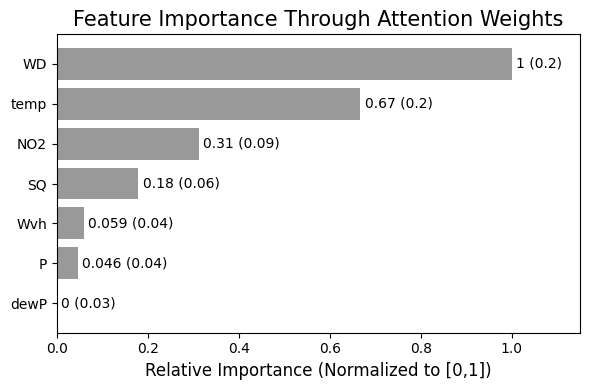

In [15]:
# Aggregate feature importance across all blocks
if feature_importance:
    plt.figure(figsize=(6, 4))
    
    # Feature names
    feature_names = ["NO2", "P", "SQ", "WD", "Wvh", "dewP", "temp"]
    
    # Stack all block importances and average them
    all_importances = []
    
    for i, importance in enumerate(feature_importance):
        # Ensure length matches by truncating if necessary
        if len(importance) > len(feature_names):
            importance = importance[:len(feature_names)]
        
        # Handle case with fewer importance values than feature names
        if len(importance) < len(feature_names):
            # Pad with zeros or handle accordingly
            padded_importance = np.zeros(len(feature_names))
            padded_importance[:len(importance)] = importance
            all_importances.append(padded_importance)
        else:
            all_importances.append(importance)
    
    # Stack and average
    avg_importance = np.mean(all_importances, axis=0)
    
    # Normalize to [0,1] scale
    if avg_importance.max() > avg_importance.min():
        normalized_importance = (avg_importance - avg_importance.min()) / (avg_importance.max() - avg_importance.min())
    else:
        normalized_importance = avg_importance
    
    # Sort by importance (ascending)
    sorted_indices = np.argsort(normalized_importance)
    sorted_importance = normalized_importance[sorted_indices]
    sorted_original = avg_importance[sorted_indices]
    sorted_features = [feature_names[idx] for idx in sorted_indices]
    
    # Create horizontal bar chart
    y_pos = np.arange(len(sorted_features))
    bars = plt.barh(y_pos, sorted_importance, align='center', color='grey', alpha=0.8)
    plt.yticks(y_pos, sorted_features)
    
    # Add value labels
    for j, (v_norm, v_orig) in enumerate(zip(sorted_importance, sorted_original)):
        plt.text(v_norm + 0.01, j, f"{v_norm:.2g} ({v_orig:.1g})", va='center', fontsize=10)
    
    plt.title('Feature Importance Through Attention Weights', fontsize=15)
    plt.xlabel('Relative Importance (Normalized to [0,1])', fontsize=12)
    plt.xlim(0, 1.15)  # Make room for labels
    
    plt.tight_layout()
    plt.show()
else:
    print("Couldn't extract feature importance. The model may not have the expected structure.")

# Comparing with a gradient based method

In [10]:
from captum.attr import IntegratedGradients
# This wrapper allows selecting a single output for attribution
class ASTGCNWrapper(torch.nn.Module):
    def __init__(self, model, edge_index):
        super().__init__()
        self.model = model
        self.edge_index = edge_index

    def forward(self, x):
        # x: (B, T, N*F)
        return self.model(x, edge_index=self.edge_index)  # Output: (B, horizon, N)


/home/nick/bachelor-project/third-copy/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# Suppose x is your input of shape (1, T, N*F)
x, _ = test_batch  # shape: (B, T, N * F)
edge_index = edges  # from PyG data
# If using edge weights: edge_weight = test_batch.edge_weight

x = x.to(device).requires_grad_()
edge_index = edge_index.to(device)



In [12]:
from captum.attr import IntegratedGradients
from tqdm import tqdm
# # 1. Wrap model
wrapped_model = ASTGCNWrapper(model, edge_index).to(device)
wrapped_model = wrapped_model.double()  # Make sure model weights are in Double precision
wrapped_model.eval()

# # 2. Prepare input and baseline
x = x.to(device).requires_grad_()
baseline = torch.zeros_like(x)

x = x.to(dtype=torch.float64).requires_grad_()  # Ensure the input is in Double precision
baseline = torch.zeros_like(x, dtype=torch.float64)  # Set the baseline as Double

# Compute attributions for all nodes and average them
N = 3  # Number of nodes (Amsterdam, Utrecht, Rotterdam)
all_attributions = []

for node_idx in tqdm(range(N),total=N-1):
    print("Computing attributions for node:", node_names[node_idx])
    # Define scalar-output forward function for this node
    def forward_func(x_input, target_node=node_idx):
        out = wrapped_model(x_input)
        return out[:, target_time, target_node]  # Shape: (B,)
    
    # Use that function in IntegratedGradients
    ig = IntegratedGradients(forward_func)
    
    # Compute attribution for this node
    node_attributions, delta = ig.attribute(
        inputs=x,
        baselines=baseline,
        return_convergence_delta=True,
        n_steps=50
    )
    
    # Store the attribution
    all_attributions.append(node_attributions)

# Stack attributions from all nodes and average them
attributions = torch.stack(all_attributions, dim=0).mean(dim=0)
print(f"Averaged attributions shape: {attributions.shape}")


  0%|          | 0/2 [00:00<?, ?it/s]

Computing attributions for node: Amsterdam


 50%|█████     | 1/2 [00:03<00:03,  3.69s/it]

Computing attributions for node: Utrecht


100%|██████████| 2/2 [00:07<00:00,  3.64s/it]

Computing attributions for node: Rotterdam


3it [00:10,  3.61s/it]                       

Averaged attributions shape: torch.Size([32, 72, 21])


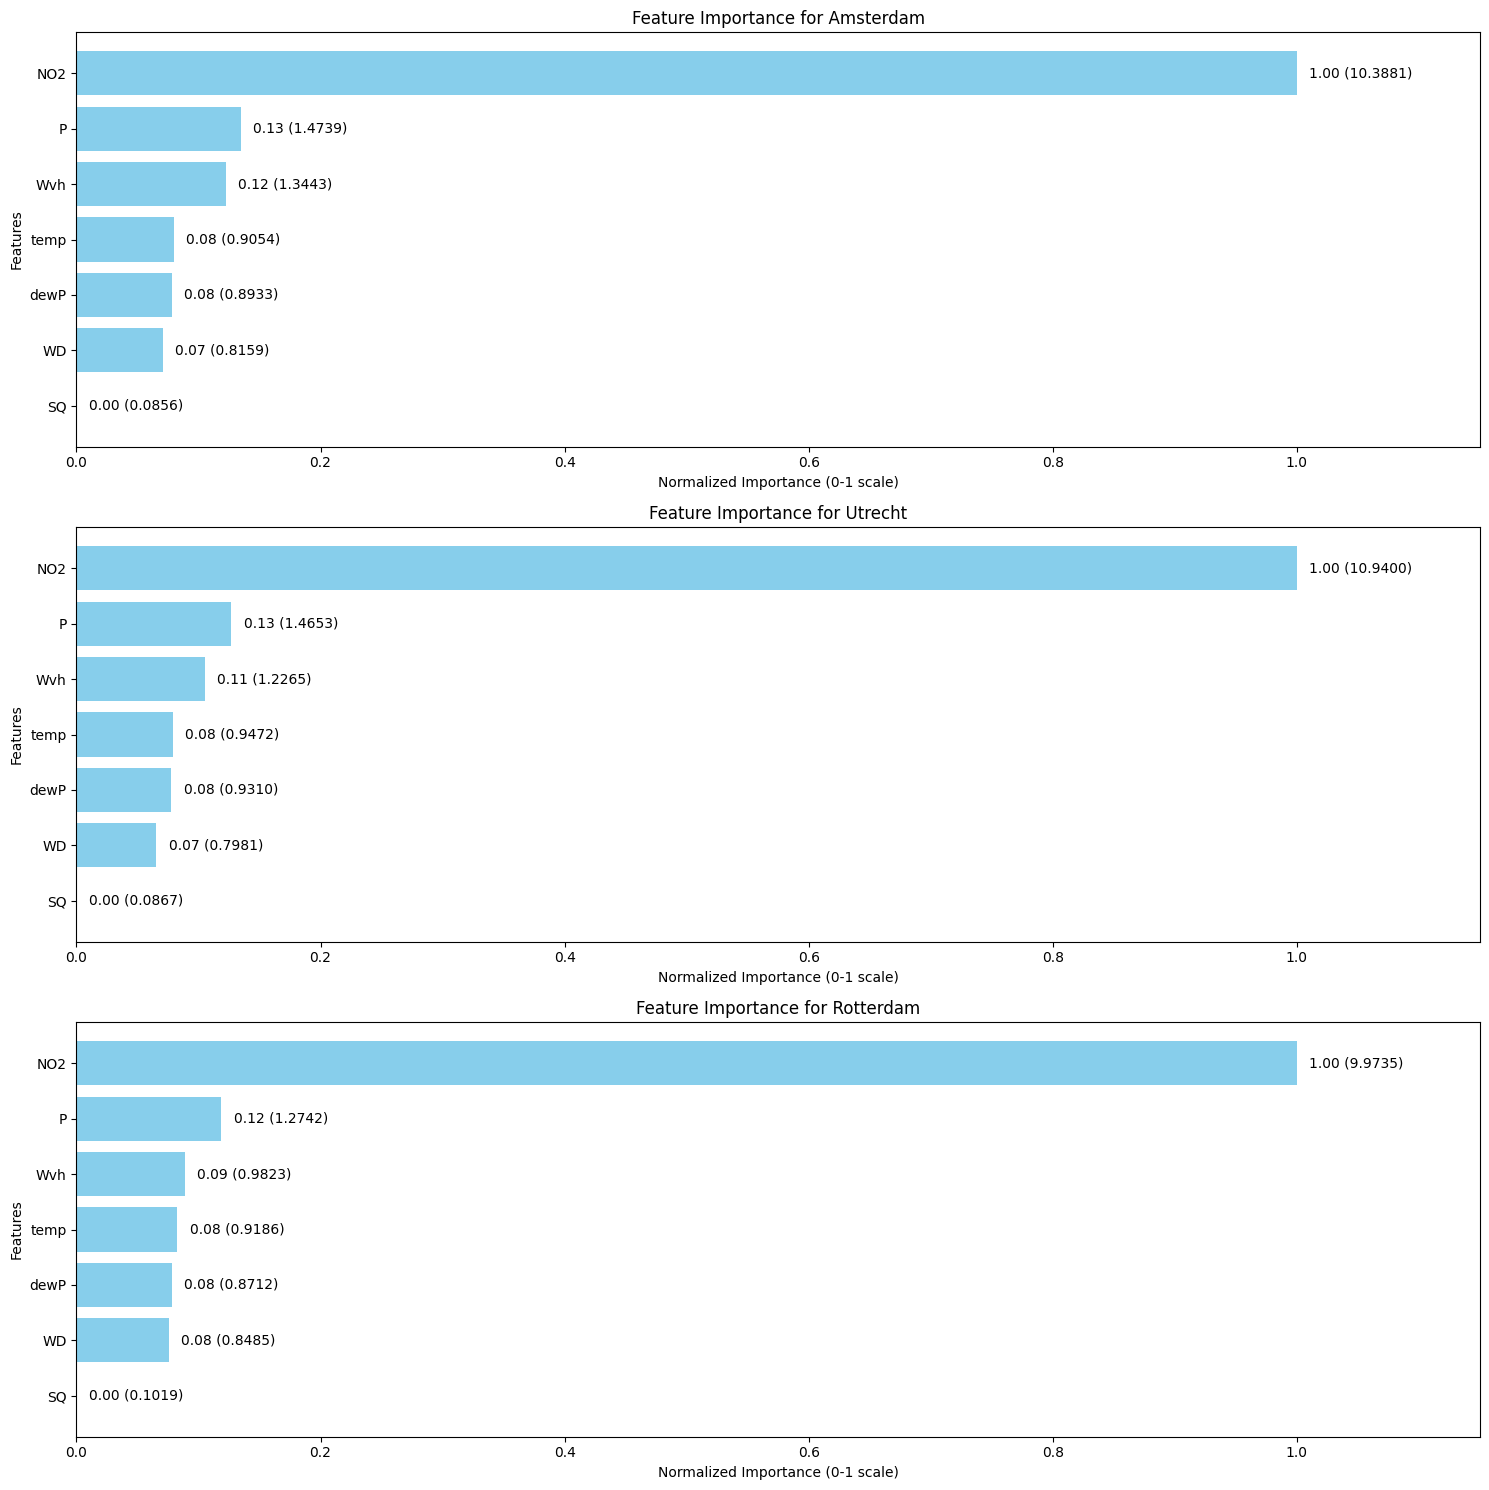

In [13]:
# Calculate node-specific feature importance from attributions
attr = attributions.abs()  # Use absolute values of attributions

# First reshape attributions to (B, T, N, F)
B, T, NF = attr.shape
N = 3  # Number of nodes
F = 7  # Number of features
attr_reshaped = attr.reshape(B, T, N, F)

# Sum over batch and time dimensions to get node-feature importance
attr_node_feature = attr_reshaped.sum(dim=(0, 1))  # shape: (N, F)

# Feature names
feature_names = ["NO2", "P", "SQ", "WD", "Wvh", "dewP", "temp"]

# Create a separate plot for each node
plt.figure(figsize=(15, 15))

for node_idx in range(N):
    # Get this node's feature importance
    node_importance = attr_node_feature[node_idx].detach().cpu().numpy()
    
    # Apply min-max normalization to scale values between 0 and 1
    min_val = node_importance.min()
    max_val = node_importance.max()
    node_importance_normalized = (node_importance - min_val) / (max_val - min_val)
    
    # Sort by importance values in ascending order
    sorted_indices = np.argsort(node_importance_normalized)
    sorted_importance = node_importance_normalized[sorted_indices]
    sorted_original = node_importance[sorted_indices]
    sorted_features = [feature_names[idx] for idx in sorted_indices]
    
    # Create subplot
    plt.subplot(3, 1, node_idx + 1)
    bars = plt.barh(sorted_features, sorted_importance, color='skyblue')
    plt.title(f"Feature Importance for {node_names[node_idx]}")
    plt.ylabel("Features")
    plt.xlabel("Normalized Importance (0-1 scale)")
    
    # Add value labels
    for i, (bar, orig) in enumerate(zip(bars, sorted_original)):
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                 f'{width:.2f} ({orig:.4f})', va='center')
    
    plt.xlim(0, 1.15)  # Make room for labels

plt.tight_layout()
plt.show()

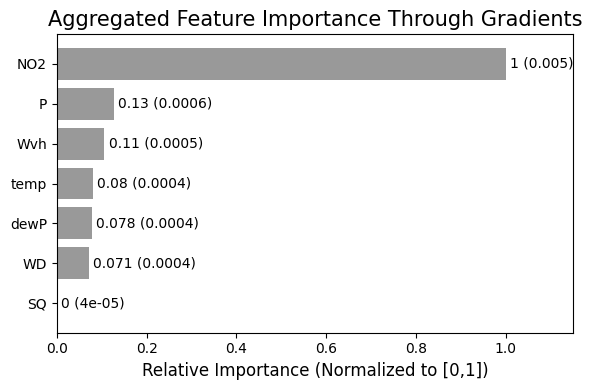

In [14]:
# Aggregate feature importance across all nodes from IntegratedGradients method using averaging
attr = attributions.abs()  # Use absolute values of attributions

# First reshape attributions to (B, T, N, F)
B, T, NF = attr.shape
N = 3  # Number of nodes
F = 7  # Number of features
attr_reshaped = attr.reshape(B, T, N, F)

# Average over batch, time, and node dimensions to get overall feature importance
attr_aggregated = attr_reshaped.mean(dim=(0, 1, 2))  # shape: (F,) - using mean instead of sum

# Convert to numpy for plotting
aggregated_importance = attr_aggregated.detach().cpu().numpy()

# Feature names
feature_names = ["NO2", "P", "SQ", "WD", "Wvh", "dewP", "temp"]

# Create figure
plt.figure(figsize=(6, 4))

# Normalize to [0,1] scale
if aggregated_importance.max() > aggregated_importance.min():
    normalized_importance = (aggregated_importance - aggregated_importance.min()) / (aggregated_importance.max() - aggregated_importance.min())
else:
    normalized_importance = aggregated_importance

# Sort by importance (ascending)
sorted_indices = np.argsort(normalized_importance)
sorted_importance = normalized_importance[sorted_indices]
sorted_original = aggregated_importance[sorted_indices]
sorted_features = [feature_names[idx] for idx in sorted_indices]

# Create horizontal bar chart
y_pos = np.arange(len(sorted_features))
bars = plt.barh(y_pos, sorted_importance, align='center', color='grey', alpha=0.8)
plt.yticks(y_pos, sorted_features)

# Add value labels
for j, (v_norm, v_orig) in enumerate(zip(sorted_importance, sorted_original)):
    plt.text(v_norm + 0.01, j, f"{v_norm:.2g} ({v_orig:.1g})", va='center', fontsize=10)

plt.title('Aggregated Feature Importance Through Gradients', fontsize=15)
plt.xlabel('Relative Importance (Normalized to [0,1])', fontsize=12)
plt.xlim(0, 1.15)  # Make room for labels

plt.tight_layout()
plt.show()